# 03. Model Evaluation and Error Econometrics

**Цель notebook.** Этот notebook завершает чистовой пайплайн для `MM`-опционов на `MXI`-фьючерс.

**Что здесь делаем:**
1. Загружаем готовые результаты pricing-моделей из `02_modelling_pipeline_clean.ipynb`.
2. Считаем итоговые ошибки на общей сопоставимой выборке.
3. Сравниваем только американские модели как корректные competing models.
4. Выносим `Black-76` в отдельный benchmark-блок как европейскую lower-bound baseline.
5. Проводим эконометрические тесты на ошибках моделей.
6. Сохраняем таблицы и текстовые результаты для дальнейшего использования в курсовой.

**Важно для интерпретации.** Поскольку рыночные контракты в выборке являются futures-style опционами американского типа, модель `Black-76` не участвует в основном ранжировании моделей как полноценный конкурент `CRR`. Она используется только как европейский benchmark без early exercise.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 1. Load Data

**Комментарий.** Берём уже готовые результаты из чистового `02`-ноутбука. Это позволяет не пересчитывать модели заново и сосредоточиться на сравнении ошибок и эконометрической части.


In [2]:
project_root = Path("/Users/maria/Desktop/Code/HSE/COURSEBOOK")
results_dir = project_root / "clear" / "results_models"
figures_dir = results_dir / "figures_03"
figures_dir.mkdir(parents=True, exist_ok=True)

pricing_df = pd.read_parquet(results_dir / "pricing_results_mxi_clean.parquet")
modelling_df = pd.read_parquet(results_dir / "modelling_sample_mxi_clean.parquet")
rate_sensitivity = pd.read_csv(results_dir / "rate_sensitivity_crr_hv_63d.csv")

pricing_df["TRADEDATE"] = pd.to_datetime(pricing_df["TRADEDATE"], errors="coerce")
pricing_df["expiry_date"] = pd.to_datetime(pricing_df["expiry_date"], errors="coerce")
modelling_df["TRADEDATE"] = pd.to_datetime(modelling_df["TRADEDATE"], errors="coerce")

print("Table 1. Loaded datasets")
display(
    pd.DataFrame(
        {
            "dataset": ["pricing_df", "modelling_df", "rate_sensitivity"],
            "rows": [len(pricing_df), len(modelling_df), len(rate_sensitivity)],
            "columns": [pricing_df.shape[1], modelling_df.shape[1], rate_sensitivity.shape[1]],
        }
    )
)


Table 1. Loaded datasets


,dataset,rows,columns
0,pricing_df,19565,70
1,modelling_df,19565,47
2,rate_sensitivity,3,7


## 2. Define Model Sets and Common Samples

**Комментарий.** Для честного ранжирования оставляем только американские модели:
- `CRR + hv_21d`
- `CRR + hv_63d`
- `CRR + garch`

`Black-76 + hv_63d` сохраняем отдельно как европейский benchmark. Это важно, потому что иначе ошибка `Black-76` смешивает две разные вещи: качество volatility input и отсутствие early exercise в модели.


In [3]:
american_models = {
    "CRR + hv_21d": {
        "price": "model_price_crr_hv_21d",
        "err": "error_crr_hv_21d",
        "abs": "abs_error_crr_hv_21d",
        "sq": "squared_error_crr_hv_21d",
        "pct": "pct_error_crr_hv_21d",
    },
    "CRR + hv_63d": {
        "price": "model_price_crr_hv_63d",
        "err": "error_crr_hv_63d",
        "abs": "abs_error_crr_hv_63d",
        "sq": "squared_error_crr_hv_63d",
        "pct": "pct_error_crr_hv_63d",
    },
    "CRR + garch": {
        "price": "model_price_crr_garch",
        "err": "error_crr_garch",
        "abs": "abs_error_crr_garch",
        "sq": "squared_error_crr_garch",
        "pct": "pct_error_crr_garch",
    },
}

euro_benchmark = {
    "Black-76 + hv_63d": {
        "price": "model_price_black76_hv_63d",
        "err": "error_black76_hv_63d",
        "abs": "abs_error_black76_hv_63d",
        "sq": "squared_error_black76_hv_63d",
        "pct": "pct_error_black76_hv_63d",
    }
}

def restrict_to_common_sample(frame: pd.DataFrame, model_specs: dict) -> pd.DataFrame:
    mask = np.ones(len(frame), dtype=bool)
    for spec in model_specs.values():
        mask &= frame[spec["price"]].notna().to_numpy()
    return frame.loc[mask].copy()

american_common = restrict_to_common_sample(pricing_df, american_models)
all_models_common = restrict_to_common_sample(pricing_df, american_models | euro_benchmark)

print("Table 2. Common sample sizes")
display(
    pd.DataFrame(
        {
            "sample": ["American models only", "American models + Black-76 benchmark"],
            "rows": [len(american_common), len(all_models_common)],
            "date_min": [american_common["TRADEDATE"].min(), all_models_common["TRADEDATE"].min()],
            "date_max": [american_common["TRADEDATE"].max(), all_models_common["TRADEDATE"].max()],
        }
    )
)


Table 2. Common sample sizes


,sample,rows,date_min,date_max
0,American models only,18058,2024-04-04,2026-05-19
1,American models + Black-76 benchmark,18058,2024-04-04,2026-05-19


## 3. Helper Functions

**Комментарий.** Ниже собраны рабочие функции для итоговых метрик, групповых таблиц и эконометрических тестов по ошибкам моделей.


In [4]:
def calc_metrics(frame: pd.DataFrame, spec: dict) -> dict:
    sub = frame.loc[frame[spec["price"]].notna()].copy()
    if sub.empty:
        return {
            "N": 0,
            "MAE": np.nan,
            "RMSE": np.nan,
            "mean_error": np.nan,
            "median_abs_error": np.nan,
            "mean_abs_pct_error": np.nan,
        }
    return {
        "N": int(len(sub)),
        "MAE": float(sub[spec["abs"]].mean()),
        "RMSE": float(np.sqrt(sub[spec["sq"]].mean())),
        "mean_error": float(sub[spec["err"]].mean()),
        "median_abs_error": float(sub[spec["abs"]].median()),
        "mean_abs_pct_error": float(sub[spec["pct"]].abs().mean()),
    }


def calc_metrics_by_group(frame: pd.DataFrame, spec: dict, group_col: str) -> pd.DataFrame:
    sub = frame.loc[frame[spec["price"]].notna()].copy()
    grouped = (
        sub.groupby(group_col, dropna=False, observed=False)
        .agg(
            N=(spec["err"], "size"),
            MAE=(spec["abs"], "mean"),
            mean_error=(spec["err"], "mean"),
            median_abs_error=(spec["abs"], "median"),
        )
        .reset_index()
    )
    rmse = (
        sub.groupby(group_col, dropna=False, observed=False)[spec["sq"]]
        .apply(lambda s: float(np.sqrt(np.mean(s))))
        .reset_index(name="RMSE")
    )
    mape = (
        sub.groupby(group_col, dropna=False, observed=False)[spec["pct"]]
        .apply(lambda s: float(np.mean(np.abs(s))))
        .reset_index(name="mean_abs_pct_error")
    )
    return grouped.merge(rmse, on=group_col, how="left").merge(mape, on=group_col, how="left")


def mean_error_test(frame: pd.DataFrame, spec: dict, model_name: str) -> dict:
    sub = frame[[spec["err"], "TRADEDATE"]].dropna().copy()
    sub["cluster"] = sub["TRADEDATE"].astype(str)
    fit = smf.ols(f'{spec["err"]} ~ 1', data=sub).fit(
        cov_type="cluster",
        cov_kwds={"groups": sub["cluster"]},
    )
    return {
        "model": model_name,
        "N": int(len(sub)),
        "mean_error": float(fit.params["Intercept"]),
        "std_error_clustered": float(fit.bse["Intercept"]),
        "t_stat": float(fit.tvalues["Intercept"]),
        "p_value": float(fit.pvalues["Intercept"]),
    }


def dm_test_daily(frame: pd.DataFrame, spec_a: dict, spec_b: dict, model_a: str, model_b: str, loss: str = "sq") -> dict:
    daily = (
        frame.groupby("TRADEDATE")[[spec_a[loss], spec_b[loss]]]
        .mean()
        .dropna()
        .reset_index()
    )
    daily["loss_diff"] = daily[spec_a[loss]] - daily[spec_b[loss]]
    fit = smf.ols("loss_diff ~ 1", data=daily).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
    return {
        "comparison": f"{model_a} minus {model_b}",
        "loss_metric": "MSE" if loss == "sq" else "MAE",
        "N_trade_dates": int(len(daily)),
        "mean_loss_diff": float(fit.params["Intercept"]),
        "std_error_hac": float(fit.bse["Intercept"]),
        "t_stat": float(fit.tvalues["Intercept"]),
        "p_value": float(fit.pvalues["Intercept"]),
    }


## 4. Overall Error Metrics for American Models

**Комментарий.** Это основная таблица сравнения моделей. Здесь сравниваются только американские модели на общей выборке, где доступны все три варианта volatility input.


In [5]:
overall_american = pd.DataFrame(
    [{"model": model_name, **calc_metrics(american_common, spec)} for model_name, spec in american_models.items()]
).sort_values("MAE").reset_index(drop=True)

print("Table 3. Overall pricing errors for American models on the common sample")
display(overall_american)


Table 3. Overall pricing errors for American models on the common sample


,model,N,MAE,RMSE,mean_error,median_abs_error,mean_abs_pct_error
0,CRR + hv_63d,18058,107.1488,140.6325,-89.7248,84.4516,3.7655
1,CRR + garch,18058,110.5361,162.0272,-66.1087,78.9983,7.3931
2,CRR + hv_21d,18058,119.3073,156.4121,-95.2581,96.8427,3.7664


**Подпись к таблице.** Чем ниже `MAE` и `RMSE`, тем лучше модель описывает settlement prices на общей сопоставимой выборке. `mean_error` показывает систематический bias, а `mean_abs_pct_error` добавляет относительную шкалу ошибки.


## 4b. TVNAE — Time-Value Normalized Absolute Error

**Комментарий.** Авторская метрика TVNAE нормирует абсолютную ошибку на временну́ю стоимость опциона (time value), а не на полную цену. Это позволяет сравнивать модели по точности прогноза именно той компоненты цены, которая чувствительна к волатильности. Фильтр `TV >= 10` исключает нестабильность при малом знаменателе.

In [ ]:
TV_THRESHOLD = 10.0

def compute_tvnae_series(frame: pd.DataFrame, spec: dict) -> pd.Series:
    df = frame.loc[frame[spec["price"]].notna()].copy()
    df["intrinsic"] = np.where(
        df["option_type_norm"] == "call",
        np.maximum(df["F"] - df["K"], 0.0),
        np.maximum(df["K"] - df["F"], 0.0),
    )
    df["time_value"] = df["market_price"] - df["intrinsic"]
    df["tvnae"] = df[spec["abs"]] / df["time_value"]
    return df.loc[df["time_value"] >= TV_THRESHOLD, ["tvnae", "time_value", "vol_regime", "DTE_bucket"]]


def calc_tvnae_metrics(frame: pd.DataFrame, spec: dict, group_col: str | None = None):
    tv_df = compute_tvnae_series(frame, spec)
    if group_col is None:
        return {
            "N_filtered": len(tv_df),
            "mean_TVNAE": float(tv_df["tvnae"].mean()),
            "median_TVNAE": float(tv_df["tvnae"].median()),
        }
    return (
        tv_df.groupby(group_col, observed=False)["tvnae"]
        .agg(N="count", mean_TVNAE="mean", median_TVNAE="median")
        .reset_index()
    )


# --- Overall TVNAE ---
tvnae_overall = pd.DataFrame([
    {"model": name, **calc_tvnae_metrics(american_common, spec)}
    for name, spec in american_models.items()
]).sort_values("mean_TVNAE").reset_index(drop=True)

print(f"Table 3b. Overall TVNAE (TV >= {TV_THRESHOLD} pts)")
display(tvnae_overall)

# --- TVNAE by vol regime ---
tvnae_by_regime = pd.concat([
    calc_tvnae_metrics(american_common, spec, "vol_regime").assign(model=name)
    for name, spec in american_models.items()
], ignore_index=True)
print("\nTable 3c. TVNAE by volatility regime")
display(tvnae_by_regime.pivot(index="model", columns="vol_regime", values="mean_TVNAE").round(3))

# --- TVNAE by DTE bucket ---
tvnae_by_dte = pd.concat([
    calc_tvnae_metrics(american_common, spec, "DTE_bucket").assign(model=name)
    for name, spec in american_models.items()
], ignore_index=True)
print("\nTable 3d. TVNAE by DTE bucket")
display(tvnae_by_dte.pivot(index="model", columns="DTE_bucket", values="mean_TVNAE").round(3))

# Save
tvnae_overall.to_csv(results_dir / "03_tvnae_overall.csv", index=False)
tvnae_by_regime.to_csv(results_dir / "03_tvnae_by_vol_regime.csv", index=False)
tvnae_by_dte.to_csv(results_dir / "03_tvnae_by_dte.csv", index=False)

## 5. Error Breakdown by Volatility Regime, DTE and Moneyness

**Комментарий.** После общего сравнения важно понять, где именно модели ошибаются сильнее: в high-volatility режимах, на длинных сроках или в хвостах по moneyness.


In [6]:
breakdown_specs = {
    "vol_regime": "Table 4. Error breakdown by volatility regime",
    "DTE_bucket": "Table 5. Error breakdown by DTE bucket",
    "moneyness_bucket": "Table 6. Error breakdown by moneyness bucket",
}

breakdown_tables = {}
for group_col, title in breakdown_specs.items():
    tables = []
    for model_name, spec in american_models.items():
        temp = calc_metrics_by_group(american_common, spec, group_col)
        temp["model"] = model_name
        tables.append(temp)
    breakdown_tables[group_col] = pd.concat(tables, ignore_index=True)
    print(title)
    display(breakdown_tables[group_col])


Table 4. Error breakdown by volatility regime


,vol_regime,N,MAE,mean_error,median_abs_error,RMSE,mean_abs_pct_error,model
0,low_vol,7684,104.1175,-103.8176,76.3250,143.8927,0.8449,CRR + hv_21d
1,mid_vol,5519,141.8138,-141.3150,123.6820,173.7385,0.6019,CRR + hv_21d
2,high_vol,4855,117.7635,-29.3552,94.9370,154.6367,11.9876,CRR + hv_21d
3,low_vol,7684,82.0777,-78.7946,58.6537,118.3153,1.3068,CRR + hv_63d
4,mid_vol,5519,128.2599,-123.5354,109.3975,158.5346,0.7803,CRR + hv_63d
5,high_vol,4855,122.8302,-68.5892,104.1905,151.1148,11.0505,CRR + hv_63d
6,low_vol,7684,78.4924,-77.1994,53.3965,113.3354,1.4301,CRR + garch
7,mid_vol,5519,122.0630,-114.7906,102.8173,152.5842,0.8099,CRR + garch
8,high_vol,4855,148.1484,6.7843,101.6000,225.5010,24.3145,CRR + garch


Table 5. Error breakdown by DTE bucket


,DTE_bucket,N,MAE,mean_error,median_abs_error,RMSE,mean_abs_pct_error,model
0,0-7,126,2.7788,-2.7775,1.3481,4.2976,0.6270,CRR + hv_21d
1,8-30,503,8.7048,-8.6902,7.0695,11.7482,0.5741,CRR + hv_21d
2,31-90,2104,36.3819,-36.3787,32.1827,46.8306,0.6095,CRR + hv_21d
3,91+,15325,135.2806,-106.9435,113.9496,168.8844,4.3304,CRR + hv_21d
4,0-7,126,3.5261,-3.5261,1.6500,5.3778,0.6831,CRR + hv_63d
5,8-30,503,10.0973,-10.0973,8.4352,13.0423,0.6315,CRR + hv_63d
6,31-90,2104,35.3924,-35.3330,33.0024,45.1145,0.6079,CRR + hv_63d
7,91+,15325,121.0378,-100.5146,99.2964,151.7211,4.3273,CRR + hv_63d
8,0-7,126,2.1719,-2.1252,1.1500,3.2271,0.5988,CRR + garch
9,8-30,503,5.3973,-4.1608,4.2367,7.3653,0.4315,CRR + garch


Table 6. Error breakdown by moneyness bucket


,moneyness_bucket,N,MAE,mean_error,median_abs_error,RMSE,mean_abs_pct_error,model
0,deep_OTM,266,63.3795,-62.3481,53.8878,86.2274,0.8464,CRR + hv_21d
1,OTM,1531,97.0469,-95.4718,93.3123,121.0248,1.1518,CRR + hv_21d
2,ATM,1950,94.1247,-88.0723,75.6108,122.5239,0.4839,CRR + hv_21d
3,ITM,3117,129.2325,-106.0375,106.0229,165.1159,0.8368,CRR + hv_21d
4,deep_ITM,11194,125.3040,-94.2612,99.6742,164.5588,5.5810,CRR + hv_21d
5,deep_OTM,266,61.5161,-60.6991,54.4320,81.5663,0.8431,CRR + hv_63d
6,OTM,1531,90.6570,-88.6047,87.0781,110.1471,1.5098,CRR + hv_63d
7,ATM,1950,88.5536,-83.8090,71.2310,111.8376,0.4811,CRR + hv_63d
8,ITM,3117,115.2119,-94.1833,89.9017,145.9576,1.3183,CRR + hv_63d
9,deep_ITM,11194,111.4828,-90.3568,85.7352,148.2446,5.3971,CRR + hv_63d


## 6. European Benchmark Block: Black-76 as a Lower Baseline

**Комментарий.** Этот блок не участвует в основном ранжировании competing models. Его задача другая: показать, насколько учёт американского exercise style меняет цену относительно европейского benchmark.


In [7]:
benchmark_compare = pd.DataFrame(
    [{"model": model_name, **calc_metrics(all_models_common, spec)} for model_name, spec in (american_models | euro_benchmark).items()]
).sort_values("MAE").reset_index(drop=True)

all_models_common["early_exercise_premium_hv63d"] = (
    all_models_common["model_price_crr_hv_63d"] - all_models_common["model_price_black76_hv_63d"]
)

premium_summary = (
    all_models_common.groupby(["vol_regime", "DTE_bucket"], dropna=False, observed=False)["early_exercise_premium_hv63d"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

black_below_intrinsic = np.where(
    all_models_common["option_type_norm"].eq("call"),
    all_models_common["model_price_black76_hv_63d"] < np.maximum(all_models_common["F"] - all_models_common["K"], 0),
    all_models_common["model_price_black76_hv_63d"] < np.maximum(all_models_common["K"] - all_models_common["F"], 0),
)

print("Table 7. Benchmark comparison including Black-76")
display(benchmark_compare)

print("Table 8. Early exercise premium for CRR(hv_63d) relative to Black-76(hv_63d)")
display(premium_summary)

print("Table 9. Diagnostic for Black-76 benchmark")
display(
    pd.DataFrame(
        {
            "metric": [
                "Observations in common benchmark sample",
                "Share of Black-76 prices below intrinsic value",
                "Mean early exercise premium",
                "Median early exercise premium",
            ],
            "value": [
                len(all_models_common),
                float(np.mean(black_below_intrinsic)),
                float(all_models_common["early_exercise_premium_hv63d"].mean()),
                float(all_models_common["early_exercise_premium_hv63d"].median()),
            ],
        }
    )
)


Table 7. Benchmark comparison including Black-76


,model,N,MAE,RMSE,mean_error,median_abs_error,mean_abs_pct_error
0,CRR + hv_63d,18058,107.1488,140.6325,-89.7248,84.4516,3.7655
1,CRR + garch,18058,110.5361,162.0272,-66.1087,78.9983,7.3931
2,CRR + hv_21d,18058,119.3073,156.4121,-95.2581,96.8427,3.7664
3,Black-76 + hv_63d,18058,156.1648,211.6440,-149.0030,109.9674,3.6200


Table 8. Early exercise premium for CRR(hv_63d) relative to Black-76(hv_63d)


,vol_regime,DTE_bucket,count,mean,median
0,low_vol,0-7,45,0.0476,-0.0000
1,low_vol,8-30,417,0.2193,0.0006
2,low_vol,31-90,1950,2.1310,0.1188
3,low_vol,91+,5272,40.6606,4.9326
4,mid_vol,0-7,81,0.0520,-0.0000
5,mid_vol,8-30,86,0.8005,-0.0000
6,mid_vol,31-90,154,2.8112,0.0434
7,mid_vol,91+,5198,64.8288,25.1753
8,high_vol,0-7,0,NaN,NaN
9,high_vol,8-30,0,NaN,NaN


Table 9. Diagnostic for Black-76 benchmark


,metric,value
0,Observations in common benchmark sample,"18,058.0000"
1,Share of Black-76 prices below intrinsic value,0.2452
2,Mean early exercise premium,59.2782
3,Median early exercise premium,9.8698


**Подпись к benchmark-блоку.** Если `Black-76` заметно уступает американским моделям, это не означает автоматически более слабую volatility estimate. Часть расхождения объясняется тем, что европейская модель не допускает early exercise.


## 7. Econometric Tests on Model Errors

**Комментарий.** Здесь добавляем три слоя формальной проверки:
1. тест на нулевую среднюю ошибку (`mean error = 0`) с кластеризацией по торговой дате;
2. парные тесты на разницу функций потерь между моделями через дневной loss differential и `HAC`-ошибки;
3. OLS-регрессию, объясняющую размер абсолютной ошибки лучшей baseline-модели.


In [8]:
mean_error_tests = pd.DataFrame(
    [mean_error_test(american_common, spec, model_name) for model_name, spec in american_models.items()]
).sort_values("p_value").reset_index(drop=True)

print("Table 10. Cluster-robust tests for zero mean pricing error")
display(mean_error_tests)


Table 10. Cluster-robust tests for zero mean pricing error

,model,N,mean_error,std_error_clustered,t_stat,p_value
0,CRR + hv_63d,18058,-89.7248,3.6218,-24.7738,0.0000
1,CRR + hv_21d,18058,-95.2581,4.1137,-23.1563,0.0000
2,CRR + garch,18058,-66.1087,4.7255,-13.9899,0.0000


In [9]:
pairwise_sq = []
pairwise_abs = []
model_names = list(american_models.keys())

for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        left = model_names[i]
        right = model_names[j]
        pairwise_sq.append(dm_test_daily(american_common, american_models[left], american_models[right], left, right, loss="sq"))
        pairwise_abs.append(dm_test_daily(american_common, american_models[left], american_models[right], left, right, loss="abs"))

dm_sq_table = pd.DataFrame(pairwise_sq).sort_values(["loss_metric", "comparison"]).reset_index(drop=True)
dm_abs_table = pd.DataFrame(pairwise_abs).sort_values(["loss_metric", "comparison"]).reset_index(drop=True)

print("Table 11. Pairwise loss-differential tests using daily mean squared errors")
display(dm_sq_table)

print("Table 12. Pairwise loss-differential tests using daily mean absolute errors")
display(dm_abs_table)


Table 11. Pairwise loss-differential tests using daily mean squared errors


,comparison,loss_metric,N_trade_dates,mean_loss_diff,std_error_hac,t_stat,p_value
0,CRR + hv_21d minus CRR + garch,MSE,540,"-2,034.0967","4,092.9474",-0.4970,0.6192
1,CRR + hv_21d minus CRR + hv_63d,MSE,540,"5,142.0180","1,143.2267",4.4978,0.0000
2,CRR + hv_63d minus CRR + garch,MSE,540,"-7,176.1147","4,316.0240",-1.6627,0.0964


Table 12. Pairwise loss-differential tests using daily mean absolute errors


,comparison,loss_metric,N_trade_dates,mean_loss_diff,std_error_hac,t_stat,p_value
0,CRR + hv_21d minus CRR + garch,MAE,540,7.8565,5.5027,1.4277,0.1534
1,CRR + hv_21d minus CRR + hv_63d,MAE,540,12.9893,3.6015,3.6067,0.0003
2,CRR + hv_63d minus CRR + garch,MAE,540,-5.1329,5.8746,-0.8737,0.3823


In [10]:
ols_df = american_common[
    [
        "TRADEDATE",
        "abs_error_crr_hv_63d",
        "vol_regime",
        "DTE_DAYS",
        "log_moneyness",
        "option_type_norm",
    ]
].dropna().copy()

ols_df["high_vol_dummy"] = (ols_df["vol_regime"] == "high_vol").astype(int)
ols_df["abs_log_moneyness"] = ols_df["log_moneyness"].abs()
ols_df["trade_date_cluster"] = ols_df["TRADEDATE"].astype(str)

error_ols_1 = smf.ols("abs_error_crr_hv_63d ~ high_vol_dummy", data=ols_df).fit(
    cov_type="cluster",
    cov_kwds={"groups": ols_df["trade_date_cluster"]},
)
error_ols_2 = smf.ols("abs_error_crr_hv_63d ~ high_vol_dummy + DTE_DAYS + abs_log_moneyness", data=ols_df).fit(
    cov_type="cluster",
    cov_kwds={"groups": ols_df["trade_date_cluster"]},
)
error_ols_3 = smf.ols("abs_error_crr_hv_63d ~ high_vol_dummy + DTE_DAYS + abs_log_moneyness + C(option_type_norm)", data=ols_df).fit(
    cov_type="cluster",
    cov_kwds={"groups": ols_df["trade_date_cluster"]},
)

print("Table 13. OLS specification 1: abs_error_crr_hv_63d on high_vol_dummy")
print(error_ols_1.summary())

print("Table 14. OLS specification 2: add DTE and abs_log_moneyness")
print(error_ols_2.summary())

print("Table 15. OLS specification 3: add option-type control")
print(error_ols_3.summary())


Table 13. OLS specification 1: abs_error_crr_hv_63d on high_vol_dummy


                             OLS Regression Results                             
Dep. Variable:     abs_error_crr_hv_63d   R-squared:                       0.011
Model:                              OLS   Adj. R-squared:                  0.011
Method:                   Least Squares   F-statistic:                     15.40
Date:                  Fri, 29 May 2026   Prob (F-statistic):           9.82e-05
Time:                          01:38:21   Log-Likelihood:            -1.0700e+05
No. Observations:                 18058   AIC:                         2.140e+05
Df Residuals:                     18056   BIC:                         2.140e+05
Df Model:                             1                                         
Covariance Type:                cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        101.382

**Подпись к эконометрическому блоку.**
- Тест `mean error = 0` отвечает на вопрос о систематическом bias.
- Pairwise loss-differential tests проверяют, различаются ли ошибки моделей статистически, а не только визуально.
- OLS здесь не является структурной моделью цены опциона; это инструмент описательной эконометрики ошибок.


## 8. Robustness Checks

**Комментарий.** Финальный шаг — проверить устойчивость результатов на альтернативных подвыборках. Это помогает понять, не держится ли победа одной модели только на каком-то узком сегменте рынка.


In [11]:
robustness_samples = {
    "full_common_sample": american_common,
    "exclude_deep_tails": american_common.loc[
        ~american_common["moneyness_bucket"].astype(str).isin(["deep_OTM", "deep_ITM"])
    ].copy(),
    "short_dte_le_91": american_common.loc[american_common["DTE_DAYS"] <= 91].copy(),
    "long_dte_gt_91": american_common.loc[american_common["DTE_DAYS"] > 91].copy(),
    "non_high_vol": american_common.loc[american_common["vol_regime"] != "high_vol"].copy(),
}

robustness_rows = []
for sample_name, sample_df in robustness_samples.items():
    for model_name, spec in american_models.items():
        row = {"sample": sample_name, "model": model_name}
        row.update(calc_metrics(sample_df, spec))
        robustness_rows.append(row)

robustness_table = pd.DataFrame(robustness_rows).sort_values(["sample", "MAE"]).reset_index(drop=True)

print("Table 16. Robustness checks across alternative subsamples")
display(robustness_table)


Table 16. Robustness checks across alternative subsamples


,sample,model,N,MAE,RMSE,mean_error,median_abs_error,mean_abs_pct_error
0,exclude_deep_tails,CRR + garch,6598,87.5893,127.8569,-61.2740,62.3867,1.1177
1,exclude_deep_tails,CRR + hv_63d,6598,101.6355,128.7476,-89.8228,83.8427,1.1153
2,exclude_deep_tails,CRR + hv_21d,6598,111.3883,143.9272,-98.2763,94.6771,0.8056
3,full_common_sample,CRR + hv_63d,18058,107.1488,140.6325,-89.7248,84.4516,3.7655
4,full_common_sample,CRR + garch,18058,110.5361,162.0272,-66.1087,78.9983,7.3931
5,full_common_sample,CRR + hv_21d,18058,119.3073,156.4121,-95.2581,96.8427,3.7664
6,long_dte_gt_91,CRR + hv_63d,15279,121.1959,151.8946,-100.6110,99.5050,4.3384
7,long_dte_gt_91,CRR + garch,15279,126.5911,175.5900,-74.1538,95.5426,8.6477
8,long_dte_gt_91,CRR + hv_21d,15279,135.4394,169.0633,-107.0170,114.1430,4.3413
9,non_high_vol,CRR + garch,13203,96.7054,131.1781,-92.9129,72.6120,1.1708


## 9. Final Figures

**Комментарий.** Здесь строим компактный набор графиков для итоговой презентации результатов. Все графики подписаны и параллельно сохраняются на диск.


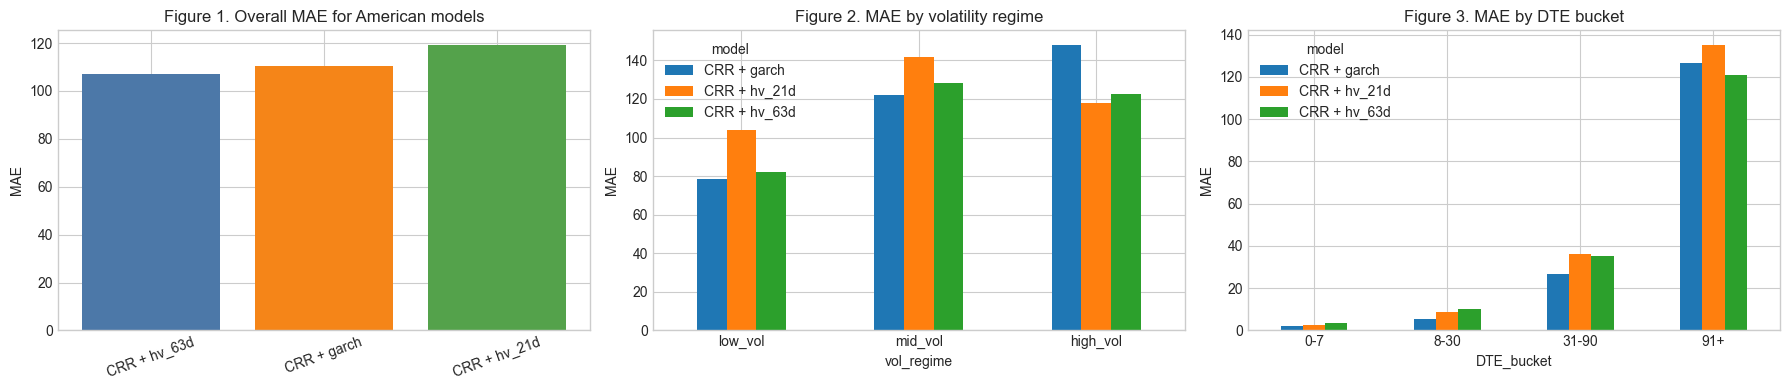

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].bar(overall_american["model"], overall_american["MAE"], color=["#4C78A8", "#F58518", "#54A24B"])
axes[0].set_title("Figure 1. Overall MAE for American models")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=20)

vol_plot = breakdown_tables["vol_regime"].dropna(subset=["vol_regime"]).pivot(index="vol_regime", columns="model", values="MAE")
vol_plot.plot(kind="bar", ax=axes[1])
axes[1].set_title("Figure 2. MAE by volatility regime")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=0)

dte_plot = breakdown_tables["DTE_bucket"].dropna(subset=["DTE_bucket"]).pivot(index="DTE_bucket", columns="model", values="MAE")
dte_plot.plot(kind="bar", ax=axes[2])
axes[2].set_title("Figure 3. MAE by DTE bucket")
axes[2].set_ylabel("MAE")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(figures_dir / "fig_01_03_model_comparison.png", dpi=150)
plt.show()


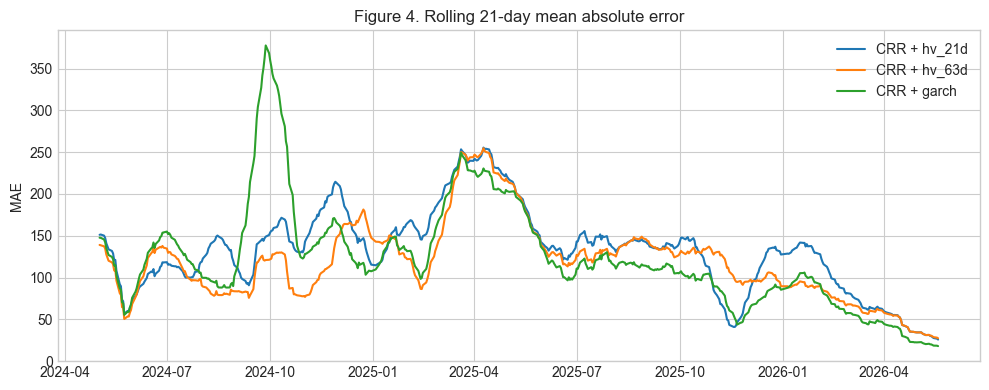

In [13]:
rolling_errors = (
    american_common.groupby("TRADEDATE")[["abs_error_crr_hv_21d", "abs_error_crr_hv_63d", "abs_error_crr_garch"]]
    .mean()
    .rolling(21)
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 4))
plt.plot(rolling_errors["TRADEDATE"], rolling_errors["abs_error_crr_hv_21d"], label="CRR + hv_21d")
plt.plot(rolling_errors["TRADEDATE"], rolling_errors["abs_error_crr_hv_63d"], label="CRR + hv_63d")
plt.plot(rolling_errors["TRADEDATE"], rolling_errors["abs_error_crr_garch"], label="CRR + garch")
plt.title("Figure 4. Rolling 21-day mean absolute error")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "fig_04_rolling_mae.png", dpi=150)
plt.show()


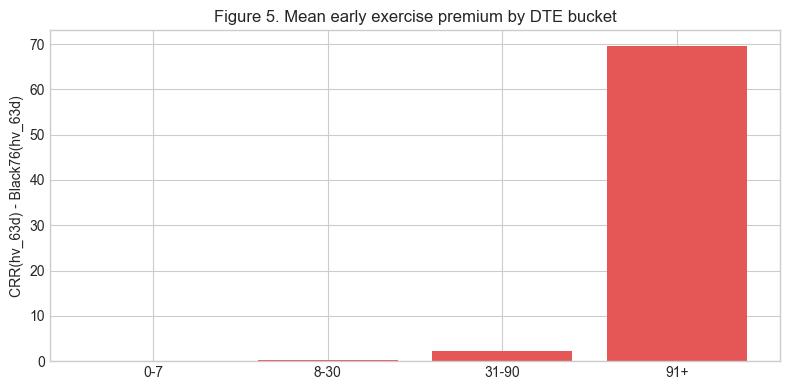

In [14]:
premium_by_dte = (
    all_models_common.groupby("DTE_bucket", dropna=False, observed=False)["early_exercise_premium_hv63d"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 4))
plt.bar(premium_by_dte["DTE_bucket"].astype(str), premium_by_dte["early_exercise_premium_hv63d"], color="#E45756")
plt.title("Figure 5. Mean early exercise premium by DTE bucket")
plt.ylabel("CRR(hv_63d) - Black76(hv_63d)")
plt.tight_layout()
plt.savefig(figures_dir / "fig_05_early_exercise_premium_by_dte.png", dpi=150)
plt.show()


## 10. Save Outputs

**Комментарий.** Сохраняем таблицы и текстовые артефакты, чтобы потом можно было без ручного копирования вставлять результаты в основной текст курсовой или в приложение.


In [15]:
overall_american.to_csv(results_dir / "03_overall_american_models.csv", index=False)
breakdown_tables["vol_regime"].to_csv(results_dir / "03_breakdown_by_vol_regime.csv", index=False)
breakdown_tables["DTE_bucket"].to_csv(results_dir / "03_breakdown_by_dte_bucket.csv", index=False)
breakdown_tables["moneyness_bucket"].to_csv(results_dir / "03_breakdown_by_moneyness_bucket.csv", index=False)
benchmark_compare.to_csv(results_dir / "03_benchmark_compare_with_black76.csv", index=False)
premium_summary.to_csv(results_dir / "03_early_exercise_premium_summary.csv", index=False)
mean_error_tests.to_csv(results_dir / "03_mean_error_tests.csv", index=False)
dm_sq_table.to_csv(results_dir / "03_pairwise_dm_sq.csv", index=False)
dm_abs_table.to_csv(results_dir / "03_pairwise_dm_abs.csv", index=False)
robustness_table.to_csv(results_dir / "03_robustness_checks.csv", index=False)

ols_text = []
ols_text.append("OLS SPECIFICATION 1\n")
ols_text.append(error_ols_1.summary().as_text())
ols_text.append("\n\nOLS SPECIFICATION 2\n")
ols_text.append(error_ols_2.summary().as_text())
ols_text.append("\n\nOLS SPECIFICATION 3\n")
ols_text.append(error_ols_3.summary().as_text())
(results_dir / "03_error_ols_results.txt").write_text("".join(ols_text))

notebook_summary = f"""# 03 Notebook Summary

- Main competing-model comparison includes only American models.
- Best American model by MAE on the common sample: {overall_american.iloc[0]['model']}.
- Black-76 is reported separately as a European benchmark without early exercise.
- Econometric tests include clustered mean-error tests, pairwise daily loss-differential tests, and OLS error regressions.
- Figures were saved to: {figures_dir}.
"""
(results_dir / "03_notebook_summary.md").write_text(notebook_summary)

print("Saved outputs to:", results_dir)
print("Saved figures to:", figures_dir)


Saved outputs to: /Users/maria/Desktop/Code/HSE/COURSEBOOK/clear/results_models
Saved figures to: /Users/maria/Desktop/Code/HSE/COURSEBOOK/clear/results_models/figures_03


## 11. Final Interpretation

**Итоговый комментарий.**
- Если `CRR + hv_63d` снова выигрывает по `MAE` и `RMSE`, это подтверждает устойчивость результата из предыдущих шагов.
- Если коэффициент при `high_vol_dummy` положителен и значим, значит ошибки действительно возрастают в high-volatility режимах.
- Если pairwise loss-differential tests значимы, различия между моделями можно интерпретировать не только как визуальные, но и как статистически подтверждённые.
- Если early exercise premium велик, то вынесение `Black-76` в отдельный benchmark-блок полностью оправдано.
